In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

db_file = "databases/Gorgon_MF_DB_Gorgon_MF_iceburner_final_week.db"

conn = sqlite3.connect(db_file)

df = pd.read_sql_query("SELECT * FROM state", conn)


In [2]:
outlier_mask = (
    (df["Y_TDT"] < 1.0)
    | (df["Y_rhoRDT"] > 60)
    | ~np.isfinite(df["Y_TDT"])
    | ~np.isfinite(df["Y_rhoRDT"])
)

outliers = df.loc[
    outlier_mask,
    [
        "index_0",
        "Y_TDT",
        "Y_rhoRDT",
        "Y_minus_peak_IFAR",
        "current",
    ],
]

display(outliers)

,index_0,Y_TDT,Y_rhoRDT,Y_minus_peak_IFAR,current
112,112,0.000000e+00,0.000000e+00,0.000000,33.582536
113,113,6.218972e-84,4.117592e+130,-6.165904,27.045951
114,114,1.026122e-135,9.821299e+181,-4.936679,31.246426
115,115,5.225875e-25,3.570593e+70,-2.692311,23.399367
186,186,2.430497e+03,2.015798e+02,-5.848790,24.566024
252,252,2.101445e+03,9.181637e+02,-9.135161,20.891646
255,255,3.685127e+03,6.943860e+01,-10.190271,34.853617


In [3]:
df = df.loc[~outlier_mask].copy()
df = df.reset_index(drop=True)

In [4]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from botorch.utils.multi_objective.box_decompositions.dominated import DominatedPartitioning
from botorch.utils.multi_objective.pareto import is_non_dominated

tkwargs = {
    "dtype": torch.double,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

objective_cols = [
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
    "Y_minus_current"

]
# input_cols = [
#     "R_outer",
#     "Pi_parameter",
#     "Be_thickness",
#     "laser_energy",
#     "rho_gas",
# ]

input_cols = ['f_laser', 'f_R_outer', 'f_Pi', 'f_Be', 'f_rho','current']

other_cols = ['P_YDT',
              'P_TDT',
              'P_BT',
              'P_imp_vel',
              'P_rhoRDT',
              'P_rhoRBe',
              'P_peak_IFAR']


Y = torch.tensor(df[objective_cols].to_numpy(dtype=float), **tkwargs)


In [5]:
y_min = Y.min(dim=0).values
y_max = Y.max(dim=0).values
y_range = (y_max - y_min).clamp_min(1e-12)

ref_point = y_min - 0.1 * y_range


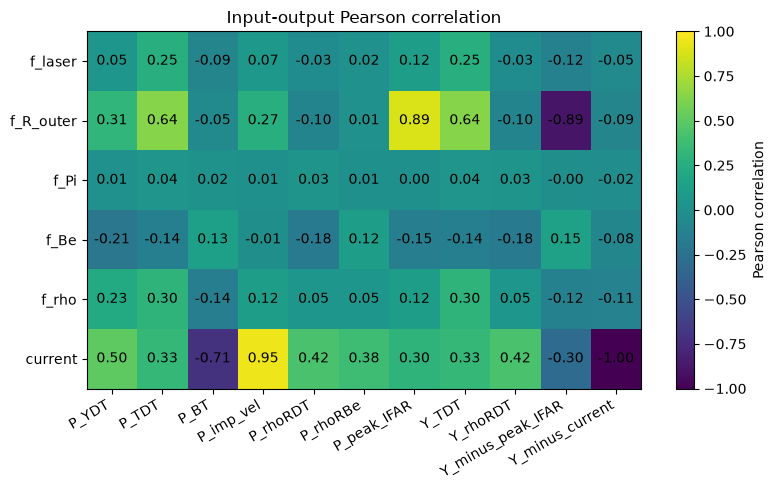

In [6]:

cols = input_cols + other_cols + objective_cols

corr = df[cols].corr(method="pearson")

# Extract only input-output block
input_output_corr = corr.loc[input_cols, other_cols + objective_cols]

plt.figure(figsize=(8, 5))
im = plt.imshow(input_output_corr, aspect="auto", vmin=-1, vmax=1)

plt.colorbar(im, label="Pearson correlation")
plt.xticks(np.arange(len(other_cols + objective_cols)), other_cols + objective_cols, rotation=30, ha="right")
plt.yticks(np.arange(len(input_cols)), input_cols)

# Write correlation values on the heatmap
for i in range(len(input_cols)):
    for j in range(len(other_cols + objective_cols)):
        value = input_output_corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.title("Input-output Pearson correlation")
plt.tight_layout()
plt.show()

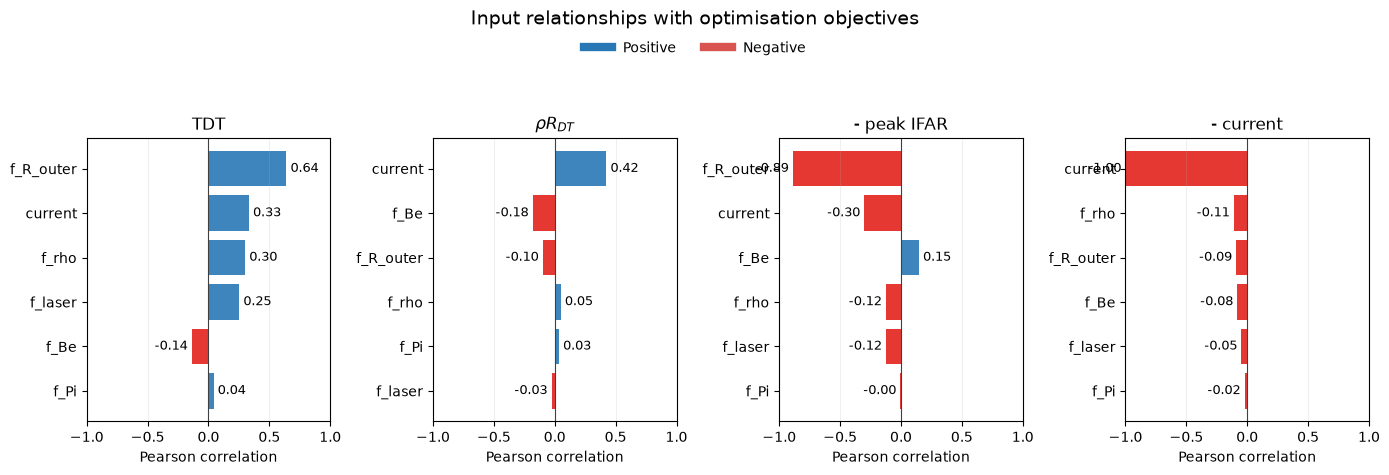

In [7]:

# Show the relationships that directly matter to the optimisation.
# Each panel ranks inputs by absolute correlation with one objective.
objective_corr = df[input_cols + objective_cols].corr().loc[input_cols, objective_cols]

objective_labels = {
    "Y_TDT": "TDT",
    "Y_rhoRDT": r"$\rho R_{DT}$",
    "Y_minus_peak_IFAR": "- peak IFAR",
    "Y_minus_current" :"- current"
} 
input_labels = {
    'f_laser' : 'f_laser',
    'f_R_outer':  "f_R_outer",
    'f_Pi' : 'f_Pi',
    'f_Be' : "f_Be",
    'f_rho' :"f_rho",
    'current' : "current"

}

fig, axes = plt.subplots(1, len(objective_cols), figsize=(14, 4.8), sharex=True)

for ax, objective in zip(axes, objective_cols):
    values = objective_corr[objective].sort_values(key=np.abs)
    colors = np.where(values >= 0, "#2878B5", "#E4221C")
    bars = ax.barh(
        [input_labels[name] for name in values.index],
        values,
        color=colors,
        alpha=0.9,
    )
    ax.axvline(0, color="0.25", linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(objective_labels[objective])
    ax.set_xlabel("Pearson correlation")
    ax.grid(axis="x", alpha=0.2)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

fig.suptitle("Input relationships with optimisation objectives", fontsize=14)
fig.legend(
    handles=[
        plt.Line2D([0], [0], color="#2878B5", lw=6, label="Positive"),
        plt.Line2D([0], [0], color="#D9534F", lw=6, label="Negative"),
    ],
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94),
)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()

In [8]:
hv = []

for n in range(1, Y.shape[0] + 1):
    Y_so_far = Y[:n]

    bd = DominatedPartitioning(
        ref_point=ref_point,
        Y=Y_so_far,
    )

    hv.append(bd.compute_hypervolume().item())

df["hypervolume"] = hv

In [9]:
df["hv_gain"] = df["hypervolume"].diff()
df.loc[0, "hv_gain"] = df.loc[0, "hypervolume"]

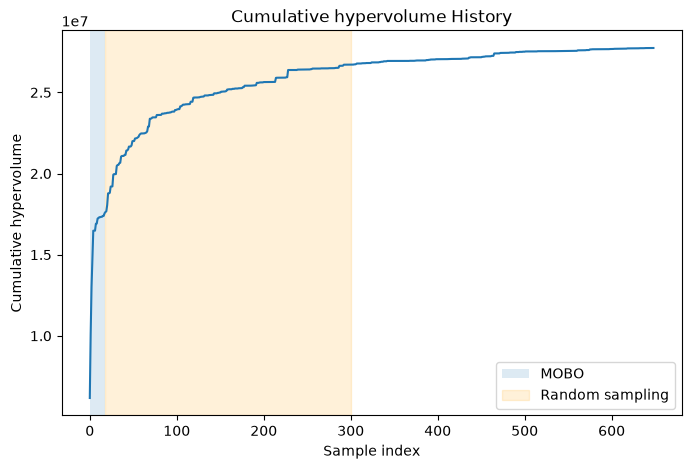

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(df["hypervolume"])
plt.axvspan(0, 17, alpha=0.15, label="MOBO")
plt.axvspan(18, 300, alpha=0.15, label="Random sampling", color = "orange")
plt.title("Cumulative hypervolume History")
plt.xlabel("Sample index")
plt.ylabel("Cumulative hypervolume")
plt.legend()
plt.show()

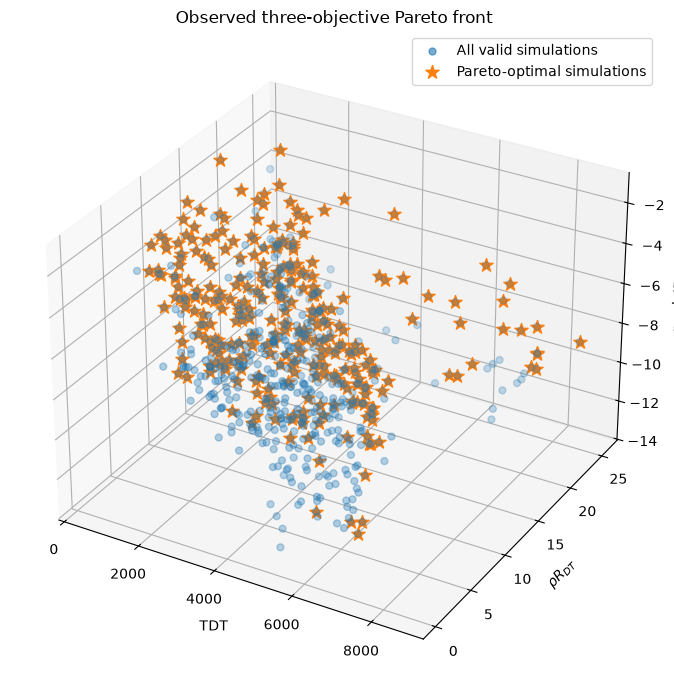

301 Pareto-optimal simulations out of 647 valid simulations.


,Y_TDT,Y_rhoRDT,Y_minus_peak_IFAR,Y_minus_current
465,8687.481950,24.448082,-8.355959,-2.985694
333,8116.175922,21.266939,-9.054748,-2.885735
228,8066.164317,20.771164,-8.840152,-2.827635
621,8047.091081,21.719008,-8.466588,-2.866119
483,8034.564542,21.798449,-8.444853,-2.826389
...,...,...,...,...
642,1248.949233,5.747616,-1.490782,-1.619635
575,949.717615,10.596217,-1.387459,-1.713255
305,927.781977,17.792460,-2.833900,-2.865967
176,898.842729,23.454069,-2.396168,-2.375730


In [11]:

from botorch.utils.multi_objective.pareto import is_non_dominated

# The three objectives in your database.
# All are maximised.
objective_cols = [
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
    "Y_minus_current"]

# Make a clean copy of the dataframe.
pareto_plot_df = df.copy()


pareto_plot_df = pareto_plot_df[
    (pareto_plot_df["Y_TDT"] > 0)
    & (pareto_plot_df["Y_rhoRDT"] > 0)
    & np.isfinite(pareto_plot_df["Y_minus_peak_IFAR"])
].copy()

# Convert objectives into a tensor.
Y_plot = torch.tensor(
    pareto_plot_df[objective_cols].to_numpy(dtype=float),
    dtype=torch.double,
)

# Find the non-dominated points.
# BoTorch assumes every objective is maximised.
pareto_mask = is_non_dominated(Y_plot).cpu().numpy()

# Dataframe containing only Pareto-optimal simulations.
pareto_df = pareto_plot_df.loc[pareto_mask].copy()

# Plot all points and highlight the Pareto front.
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pareto_plot_df["Y_TDT"],
    pareto_plot_df["Y_rhoRDT"],
    pareto_plot_df["Y_minus_peak_IFAR"],
    alpha=0.6,
    s=25,
    label="All valid simulations",
)

ax.scatter(
    pareto_df["Y_TDT"],
    pareto_df["Y_rhoRDT"],
    pareto_df["Y_minus_peak_IFAR"],
    marker="*",
    s=100,
    depthshade=False,
    label="Pareto-optimal simulations",
)

ax.set_xlabel("TDT")
ax.set_ylabel(r"$\rho R_{DT}$")
ax.set_zlabel("- peak IFAR")

ax.set_title("Observed three-objective Pareto front")
ax.legend()

plt.tight_layout()
plt.show()

print(
    f"{len(pareto_df)} Pareto-optimal simulations "
    f"out of {len(pareto_plot_df)} valid simulations."
)

# Display the Pareto-optimal objective values.
display(
    pareto_df[objective_cols]
    .sort_values("Y_TDT", ascending=False)
)

### Inspect a Pareto (non-dominated) point

The table below gives each Pareto point both its plotted DataFrame index and its original database simulation index (`index_0`). Use either index with `inspect_dominating_point(...)` to recover the corresponding design inputs.

In [12]:
# Build an index lookup for the Pareto points found in the previous cell.
# "df_index" is the row index shown beside points in pandas/plots.
# "simulation_index" is the original database index stored in index_0.

def list_dominating_points(sort_by="Y_TDT", ascending=False):
    """Return a compact lookup table for all current Pareto points."""
    lookup = pareto_df.copy()
    lookup.insert(0, "df_index", lookup.index)

    if "index_0" in lookup.columns:
        lookup.insert(1, "simulation_index", lookup["index_0"])
    else:
        lookup.insert(1, "simulation_index", lookup.index)

    shown_cols = [
        "df_index",
        "simulation_index",
        *[col for col in input_cols if col in lookup.columns],
        *[col for col in objective_cols if col in lookup.columns],
    ]

    if sort_by not in lookup.columns:
        raise KeyError(
            f"sort_by={sort_by!r} is not a column. "
            f"Choose from: {list(lookup.columns)}"
        )

    return (
        lookup[shown_cols]
        .sort_values(sort_by, ascending=ascending)
        .reset_index(drop=True)
    )


def _reconstruct_physical_inputs(row):
    """Convert the current-scaled multipliers into dimensional input values."""
    required = {"f_laser", "f_R_outer", "f_Pi", "f_Be", "f_rho", "current"}
    if not required.issubset(row.index):
        return None

    current = float(row["current"])
    scale = current / 20.0

    laser_energy = float(row["f_laser"]) * 0.84e3 * scale**2.529
    R_outer = float(row["f_R_outer"]) * 2.79e-3 * scale**0.381
    Pi_parameter = float(row["f_Pi"]) * 1.20e-7 * scale**2

    scaled_be_reference = (
        2.79e-3 * scale**0.381
        - 2.325e-3 * scale**0.206
    )
    Be_thickness = float(row["f_Be"]) * scaled_be_reference
    rho_gas = float(row["f_rho"]) * 2.25 * scale**0.529

    return pd.Series(
        {
            "laser_energy_J": laser_energy,
            "R_outer_m": R_outer,
            "Pi_parameter_kg_per_m": Pi_parameter,
            "Be_thickness_m": Be_thickness,
            "rho_gas_kg_per_m3": rho_gas,
            "current_MA": current,
        },
        name="physical_value",
    )


def inspect_dominating_point(point_index, index_type="df_index"):
    """
    Inspect one Pareto/non-dominated simulation.

    Parameters
    ----------
    point_index : int or float
        Index identifying the simulation.
    index_type : {"df_index", "simulation_index", "pareto_position"}
        - "df_index": pandas row index used in the Pareto plot/table.
        - "simulation_index": original database index from index_0.
        - "pareto_position": zero-based row in list_dominating_points().

    Returns
    -------
    dict
        Selected row, multiplier inputs, reconstructed physical inputs,
        objective values, and diagnostic outputs.
    """
    valid_index_types = {"df_index", "simulation_index", "pareto_position"}
    if index_type not in valid_index_types:
        raise ValueError(
            f"index_type must be one of {sorted(valid_index_types)}, "
            f"not {index_type!r}."
        )

    if index_type == "df_index":
        if point_index not in pareto_df.index:
            raise KeyError(
                f"DataFrame index {point_index!r} is not on the current Pareto front. "
                "Run display(list_dominating_points()) to see valid indices."
            )
        row = pareto_df.loc[point_index]
        df_index = point_index

    elif index_type == "simulation_index":
        if "index_0" not in pareto_df.columns:
            raise KeyError("The dataframe has no index_0 database-index column.")

        matches = pareto_df.index[pareto_df["index_0"] == point_index].tolist()
        if not matches:
            raise KeyError(
                f"Simulation index {point_index!r} is not on the current Pareto front. "
                "Run display(list_dominating_points()) to see valid indices."
            )
        if len(matches) > 1:
            raise ValueError(
                f"Simulation index {point_index!r} appears more than once: {matches}."
            )
        df_index = matches[0]
        row = pareto_df.loc[df_index]

    else:  # pareto_position
        lookup = list_dominating_points()
        position = int(point_index)
        if position < 0 or position >= len(lookup):
            raise IndexError(
                f"pareto_position must be between 0 and {len(lookup) - 1}."
            )
        df_index = lookup.loc[position, "df_index"]
        row = pareto_df.loc[df_index]

    simulation_index = row["index_0"] if "index_0" in row.index else df_index

    multiplier_inputs = row[[c for c in input_cols if c in row.index]].copy()
    multiplier_inputs.name = "value"

    physical_inputs = _reconstruct_physical_inputs(row)

    objectives = row[[c for c in objective_cols if c in row.index]].copy()
    objectives.name = "value"

    diagnostics = row[[c for c in other_cols if c in row.index]].copy()
    diagnostics.name = "value"

    print(f"DataFrame index: {df_index}")
    print(f"Database simulation index (index_0): {simulation_index}")

    print("\nOptimisation inputs / multipliers:")
    display(multiplier_inputs.to_frame())

    if physical_inputs is not None:
        print("Reconstructed physical inputs:")
        display(physical_inputs.to_frame())

    print("Objective values:")
    display(objectives.to_frame())

    if not diagnostics.empty:
        print("Diagnostic outputs:")
        display(diagnostics.to_frame())

    return {
        "df_index": df_index,
        "simulation_index": simulation_index,
        "row": row,
        "multiplier_inputs": multiplier_inputs,
        "physical_inputs": physical_inputs,
        "objectives": objectives,
        "diagnostics": diagnostics,
    }


# First inspect this table to find the point/index you want.

# Examples:
# result = inspect_dominating_point(35, index_type="df_index")
# result = inspect_dominating_point(35, index_type="simulation_index")
# result = inspect_dominating_point(0, index_type="pareto_position")


In [13]:
# Create and display the table
pareto_table = list_dominating_points()
display(pareto_table)

# Save the table as CSV
pareto_table.to_csv(
    "pareto_dominating_points_current.csv",
    index=False,
)

print("Saved as: pareto_dominating_points_current.csv")

,df_index,simulation_index,f_laser,f_R_outer,f_Pi,f_Be,f_rho,current,Y_TDT,Y_rhoRDT,Y_minus_peak_IFAR,Y_minus_current
0,465,472,1.157335,1.044085,1.007643,0.526632,1.400220,59.713871,8687.481950,24.448082,-8.355959,-2.985694
1,333,340,1.322602,1.048147,0.998727,0.529421,1.308687,57.714708,8116.175922,21.266939,-9.054748,-2.885735
2,228,233,1.111074,1.047349,1.002250,0.523718,1.408028,56.552690,8066.164317,20.771164,-8.840152,-2.827635
3,621,628,0.559899,1.040460,1.002927,0.536277,1.357395,57.322370,8047.091081,21.719008,-8.466588,-2.866119
4,483,490,0.775616,1.048190,1.015585,0.511598,1.392587,56.527774,8034.564542,21.798449,-8.444853,-2.826389
...,...,...,...,...,...,...,...,...,...,...,...,...
296,642,649,0.827351,0.908853,0.984184,0.526383,0.560155,32.392690,1248.949233,5.747616,-1.490782,-1.619635
297,575,582,0.676903,0.919924,1.004526,0.502559,0.644520,34.265107,949.717615,10.596217,-1.387459,-1.713255
298,305,312,1.008054,0.910885,1.004930,1.241254,0.690815,57.319347,927.781977,17.792460,-2.833900,-2.865967
299,176,180,1.283647,0.941984,1.004555,0.576081,1.241521,47.514597,898.842729,23.454069,-2.396168,-2.375730


Saved as: pareto_dominating_points_current.csv


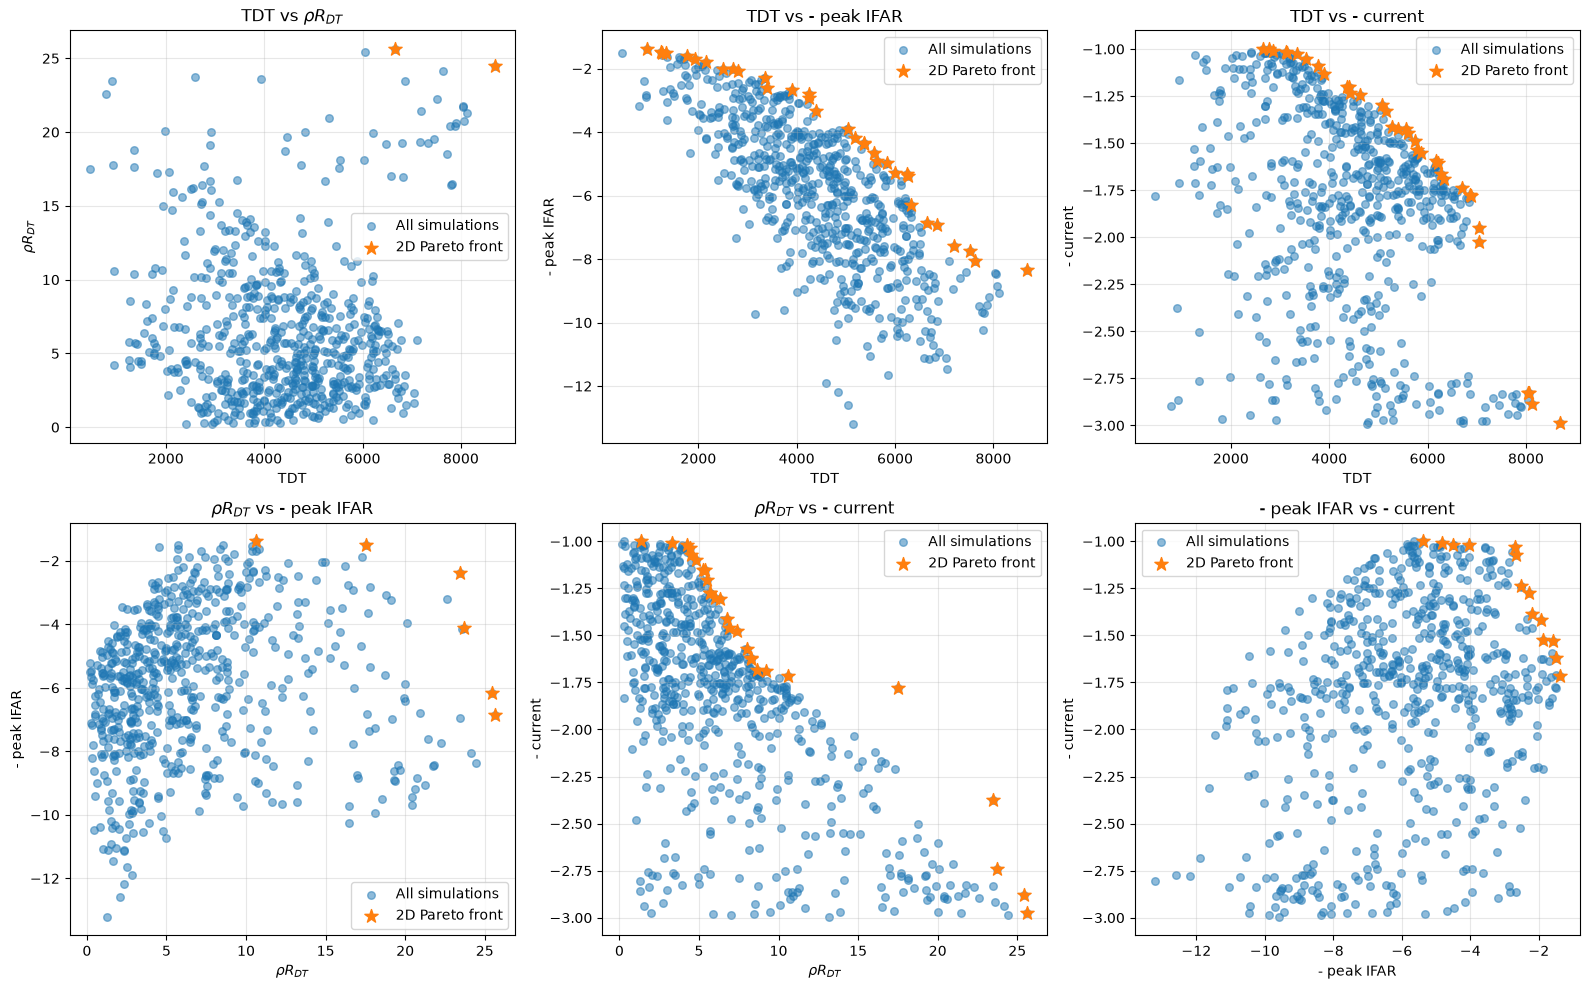

In [14]:

from itertools import combinations


objective_cols = [
    "Y_TDT",
    "Y_rhoRDT",
    "Y_minus_peak_IFAR",
    "Y_minus_current"
]

objective_labels = {
    "Y_TDT": "TDT",
    "Y_rhoRDT": r"$\rho R_{DT}$",
    "Y_minus_peak_IFAR": "- peak IFAR",
    "Y_minus_current" :"- current"
}


objective_pairs = list(combinations(objective_cols, 2))

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10),
)

# Convert the 2D axes array into a flat array.
axes = axes.ravel()

for ax, (x_col, y_col) in zip(axes, objective_pairs):

    # Extract the current pair of objectives.
    Y_pair = torch.tensor(
        pareto_plot_df[[x_col, y_col]].to_numpy(dtype=float),
        dtype=torch.double,
    )

    # Recalculate the Pareto front using only these two objectives.
    pair_pareto_mask = is_non_dominated(Y_pair).cpu().numpy()

    pair_pareto_df = pareto_plot_df.loc[pair_pareto_mask].copy()

    # Sort by the x objective so the Pareto-front line is drawn correctly.
    pair_pareto_df = pair_pareto_df.sort_values(x_col)

    # Plot all valid simulations.
    ax.scatter(
        pareto_plot_df[x_col],
        pareto_plot_df[y_col],
        alpha=0.5,
        s=30,
        label="All simulations",
    )

    # Plot the 2D Pareto-optimal points.
    ax.scatter(
        pair_pareto_df[x_col],
        pair_pareto_df[y_col],
        marker="*",
        s=100,
        label="2D Pareto front",
        zorder=3,
    )

    ax.set_xlabel(objective_labels[x_col])
    ax.set_ylabel(objective_labels[y_col])

    ax.set_title(
        f"{objective_labels[x_col]} vs "
        f"{objective_labels[y_col]}"
    )

    ax.grid(alpha=0.3)
    ax.legend()


# axes[0].set_ylim(0,20)
# axes[2].set_xlim(0,20)
plt.tight_layout()
plt.show()

In [15]:

# import corner

# corner_cols = [
#     "laser_energy",
#     "R_outer",
#     "Pi_parameter",
#     "Be_thickness",
#     "rho_gas",
#     "Y_TDT",
#     "Y_rhoRDT",
#     "Y_minus_peak_IFAR",
# ]

# # Convert to numeric and remove invalid rows
# corner_df = (
#     df[corner_cols].iloc[70:250]
#     .apply(pd.to_numeric, errors="coerce")
#     .replace([np.inf, -np.inf], np.nan)
#     .dropna()
# )

# # Each row is one simulation, and each column is one parameter/objective
# samples = corner_df.to_numpy()

# print("(# simulation samples, # variables)")
# print("Samples shape:", samples.shape)

# labels = [
#     "Laser energy",
#     r"$R_{\mathrm{outer}}$",
#     r"$\Pi$",
#     "Be thickness",
#     r"$\rho_{\mathrm{gas}}$",
#     r"$Y_{TDT}$",
#     r"$Y_{\rho RDT}$",
#     r"$-\mathrm{peak\ IFAR}$",
# ]

# fig = corner.corner(
#     samples,
#     labels=labels,
#     bins=20,
#     show_titles=True,
#     title_fmt=".3g",
#     plot_datapoints=True,
#     plot_density=True,
#     fill_contours=False,
#     quantiles=[0.16, 0.50, 0.84],
#     label_kwargs={"fontsize": 11},
#     title_kwargs={"fontsize": 9},
# )

# fig.set_size_inches(14, 14)
# plt.show()

In [16]:
current_scale = df["current"] / 20.0

# Reconstruct the dimensional design variables
df["R_outer_actual"] = (
    df["f_R_outer"]
    * 2.79e-3
    * current_scale**0.381
)

be_thickness_actual = df["f_Be"] * (
    2.79e-3 * current_scale**0.381
    - 2.325e-3 * current_scale**0.206
)

Pi_actual = (
    df["f_Pi"]
    * 1.20e-7
    * current_scale**2
)

inner_Be_radius = df["R_outer_actual"] - be_thickness_actual

rho_be = 1.85e3
rho_ice = 0.92e3

m_shell = Pi_actual / df["R_outer_actual"]**2

m_be = (
    np.pi
    * (df["R_outer_actual"]**2 - inner_Be_radius**2)
    * rho_be
)

m_ice = m_shell - m_be

ice_inner_radius = np.sqrt(
    inner_Be_radius**2
    - m_ice / (np.pi * rho_ice)
)

df["DT_ice_thickness"] = inner_Be_radius - ice_inner_radius
df["DT_ice_thickness_um"] = df["DT_ice_thickness"] * 1e6

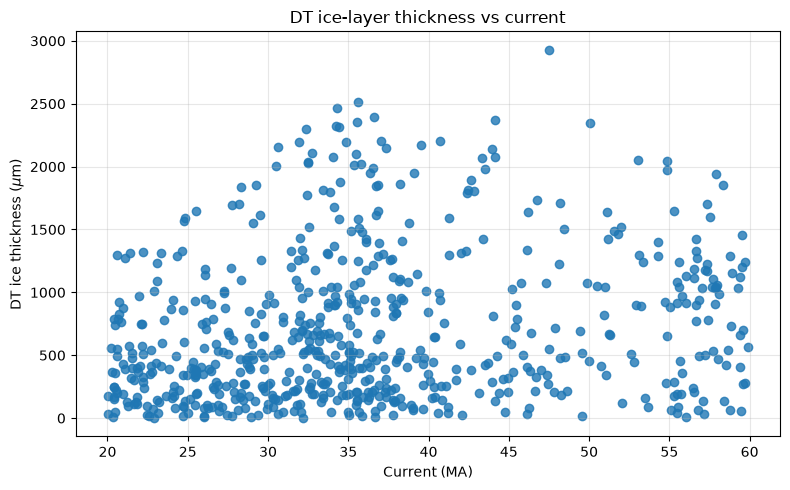

Pearson correlation: 0.20081184631033897


In [17]:
plot_df = df.sort_values("current")

plt.figure(figsize=(8, 5))
plt.scatter(
    plot_df["current"],
    plot_df["DT_ice_thickness_um"],
    alpha=0.8,
)

plt.xlabel("Current (MA)")
plt.ylabel(r"DT ice thickness ($\mu$m)")
plt.title("DT ice-layer thickness vs current")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Pearson correlation:",
    plot_df["current"].corr(plot_df["DT_ice_thickness_um"])
)